# Cleaning `merc_engineered.csv` + grounded OBD-II features

Turns the enriched interim dataset (`data/interim/merc_engineered.csv`) into a
**model-ready** dataset at `data/processed/merc_processed.csv`, applying the cleaning
recommendations from `01_data_exploration/02_eda_merc_engineered.ipynb` and adding four
**simulated OBD-II / vehicle-health** features.

> **Every new feature is grounded in columns that already exist in this dataset** — no
> invented owner/service records, no random coolant/battery draws. Small *seeded* noise
> (seed 42) is added only where it represents genuine unit-to-unit variance. These are
> simulated demonstrations, **not** real sensor telemetry.

**Cleaning steps:** drop duplicate listings → backfill mis-coded `engine_size` from
`displacement_cc` → null broken `torque_nm` → drop constant `spec_matched` → drop rows
with any remaining missing spec value (complete-case).

**New features (grounding):**

| Feature | Grounded in | Noise |
|---|---|---|
| `estimated_annual_mileage` | `mileage / age` | none |
| `dtc_fault_count` | `age`, `mileage` (wear) | seeded Poisson |
| `brake_life_pct` | `mileage`, `front_brake`/`rear_brake` type | small seeded Gaussian |
| `health_score` | real `battery_soh`, real `trans_adapt_offset`, `mileage`, + the two above | none |

## 1 · Setup & load

In [1]:
import pathlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 140)

SEED = 42
RNG = np.random.default_rng(SEED)   # single seeded generator -> reproducible features

# Resolve repo root by walking up until data/interim exists
_root = pathlib.Path.cwd()
while not (_root / "data" / "interim").exists() and _root != _root.parent:
    _root = _root.parent
IN_PATH = _root / "data" / "interim" / "merc_engineered.csv"
OUT_PATH = _root / "data" / "processed" / "merc_processed.csv"
print("input :", IN_PATH)
print("output:", OUT_PATH)

df = pd.read_csv(IN_PATH)
n_start = len(df)
print("loaded shape:", df.shape)
df.head()

input : C:\Users\Chan Zheng Shao\OneDrive\Desktop\Github Repo\Clorox_Mercedes_26\data\interim\merc_engineered.csv
output: C:\Users\Chan Zheng Shao\OneDrive\Desktop\Github Repo\Clorox_Mercedes_26\data\processed\merc_processed.csv


loaded shape: (36819, 26)


,model_class,year,mileage,transmission,fuel_type,engine_size,price_rm,source_market,age,variant,displacement_cc,n_cylinders,n_gears,top_speed_kmh,torque_nm,accel_0_100_s,boot_l,engine_config,aspiration,gear_type,front_brake,rear_brake,spec_matched,match_level,battery_soh,trans_adapt_offset
0,SLK,2005.0,101388.420,Automatic,Petrol,1.8,30680,uk,21.0,MERCEDES BENZ SLK (R171) (2004-2008),1796.0,4.0,6.0,230.0,240.0,7.9,207.0,L4,naturally_aspirated,manual,Ventilated Discs,Discs,True,displacement,38.67,-0.0731
1,S,2017.0,43452.180,Automatic,Hybrid,2.1,206193,uk,9.0,MERCEDES BENZ S-Class (2017-2020),2143.0,4.0,7.0,240.0,500.0,7.6,510.0,L4,turbo,automatic,Ventilated Discs,Ventilated Discs,True,displacement,85.51,-0.0309
2,SL,2016.0,9977.908,Automatic,Petrol,5.5,294693,uk,10.0,MERCEDES BENZ SL 63 AMG (R231) (2016-Present),5461.0,8.0,7.0,249.0,900.0,4.1,365.0,V8,turbo,automatic,Ventilated Discs,Ventilated Discs,True,displacement,65.18,-0.0213
3,G,2016.0,25749.440,Automatic,Petrol,4.0,365493,uk,10.0,MERCEDES BENZ G-Class 4x4 squared (W463) (2015...,3982.0,8.0,7.0,209.0,610.0,7.4,481.0,V8,turbo,automatic,Ventilated Discs,Ventilated Discs,True,displacement,65.44,-0.0299
4,G,2016.0,6437.360,Automatic,Petrol,4.0,436293,uk,10.0,MERCEDES BENZ G-Class 4x4 squared (W463) (2015...,3982.0,8.0,7.0,209.0,610.0,7.4,481.0,V8,turbo,automatic,Ventilated Discs,Ventilated Discs,True,displacement,59.81,-0.0232


## 2 · Cleaning

Applied in order, tracking the row count at each step (the "ledger"). Nothing in
`data/interim/` is modified — all edits are on the in-memory copy.

In [2]:
ledger = [("loaded", len(df))]

# 2a. Drop duplicate listings (identical on the raw listing columns; keep first).
raw_cols = ["model_class", "year", "mileage", "transmission",
            "fuel_type", "engine_size", "price_rm", "source_market"]
n_dupes = int(df.duplicated(subset=raw_cols).sum())
df = df.drop_duplicates(subset=raw_cols, keep="first").reset_index(drop=True)
ledger.append((f"drop {n_dupes} duplicate listings", len(df)))

# 2b. Backfill mis-coded engine_size (== 0) from displacement_cc (litres = cc / 1000).
mask0 = df["engine_size"] == 0
n_backfill = int(mask0.sum())
df.loc[mask0, "engine_size"] = (df.loc[mask0, "displacement_cc"] / 1000).round(1)
ledger.append((f"backfill {n_backfill} engine_size==0 from displacement", len(df)))

# 2c. Null broken torque_nm (scrape errors, e.g. 320,440 Nm) so complete-case drops them.
n_torque = int((df["torque_nm"] > 2000).sum())
df.loc[df["torque_nm"] > 2000, "torque_nm"] = np.nan
ledger.append((f"null {n_torque} broken torque_nm (>2000)", len(df)))

# 2d. Drop constant column spec_matched (all True -> zero variance).
if "spec_matched" in df.columns and df["spec_matched"].nunique() == 1:
    df = df.drop(columns=["spec_matched"])
    ledger.append(("drop constant spec_matched column", len(df)))

# 2e. Complete-case: drop rows with any missing spec value (incl. the nulled torque rows).
spec_cols = ["n_gears", "top_speed_kmh", "torque_nm", "accel_0_100_s", "boot_l"]
before = len(df)
df = df.dropna(subset=spec_cols).reset_index(drop=True)
ledger.append((f"complete-case drop {before - len(df)} rows with missing specs", len(df)))

pd.DataFrame(ledger, columns=["step", "rows"])

,step,rows
0,loaded,36819
1,drop 7 duplicate listings,36812
2,backfill 10 engine_size==0 from displacement,36812
3,null 5 broken torque_nm (>2000),36812
4,drop constant spec_matched column,36812
5,complete-case drop 6225 rows with missing specs,30587


In [3]:
# Post-clean assertions
assert df.isna().sum().sum() == 0, "unexpected missing values remain"
assert not df.duplicated(subset=raw_cols).any(), "duplicates remain"
assert (df["engine_size"] > 0).all(), "engine_size still has zeros"
assert df["torque_nm"].max() < 2000, "broken torque remains"
assert "spec_matched" not in df.columns, "spec_matched not dropped"
print("cleaning assertions passed |", f"{n_start} -> {len(df)} rows "
      f"({len(df)/n_start*100:.1f}% kept)")

cleaning assertions passed | 36819 -> 30587 rows (83.1% kept)


## 3 · Grounded OBD-II feature engineering

Each function below is a pure function of **existing columns**, in the same
`base signal (+ seeded noise) -> clip` style as the pipeline's `battery_soh`. Computed in
dependency order: annual mileage → faults → brake life → health score.

In [4]:
# --- brake-life decay constants (km) by disc/drum type -----------------------
# Larger k = wears slower. Grounded in the front_brake / rear_brake type columns.
BRAKE_K = {
    "Ventilated Discs": 300_000,   # best cooling / longevity
    "Discs":            220_000,
    "Drums":            260_000,
    "Unknown":          250_000,   # neutral default
}


def estimated_annual_mileage(mileage, age):
    """km driven per year = mileage / age. Grounded in mileage + age (age>=1 here)."""
    return mileage / np.maximum(age, 1)


def dtc_fault_expected(age, mileage):
    """Deterministic expected DTC count: rises with age and mileage (wear).
    Grounded in age + mileage; the realised count is a seeded Poisson draw."""
    return 0.02 * age + 0.8 * (mileage / 1e5)


def brake_life_pct_base(mileage, front_type, rear_type):
    """Remaining brake life % = 100*exp(-mileage/k), taking the worse of front/rear.
    Grounded in mileage + the real brake-type columns."""
    kf = np.array([BRAKE_K.get(t, BRAKE_K["Unknown"]) for t in front_type])
    kr = np.array([BRAKE_K.get(t, BRAKE_K["Unknown"]) for t in rear_type])
    life_f = 100 * np.exp(-mileage / kf)
    life_r = 100 * np.exp(-mileage / kr)
    return np.minimum(life_f, life_r)      # worse axle drives the value


def health_score(mileage, battery_soh, trans_adapt_offset, fault_count, brake_life):
    """0-100 penalty score (obd_sim.compute_health_score style) from GROUNDED inputs:
    real battery_soh, real trans_adapt_offset, mileage, and the grounded fault/brake
    features. No random coolant/battery values."""
    battery_pen = (100 - battery_soh) * 0.25                       # real SoH
    fault_pen   = np.minimum(25, fault_count * 6)                  # grounded
    mileage_pen = np.clip((mileage - 100_000) / 20_000, 0, 15)     # real
    brake_pen   = (100 - brake_life) * 0.15                        # grounded
    trans_pen   = np.minimum(10, -trans_adapt_offset * 50)         # real (offset <= 0)
    score = 100 - (battery_pen + fault_pen + mileage_pen + brake_pen + trans_pen)
    return np.clip(score, 0, 100)

In [5]:
# Apply in dependency order using the single seeded RNG.
df["estimated_annual_mileage"] = estimated_annual_mileage(df["mileage"], df["age"]).round(1)

lam = dtc_fault_expected(df["age"].to_numpy(), df["mileage"].to_numpy())
df["dtc_fault_count"] = RNG.poisson(lam).astype(int)

brake = brake_life_pct_base(df["mileage"].to_numpy(),
                            df["front_brake"].to_numpy(), df["rear_brake"].to_numpy())
brake = np.clip(brake + RNG.normal(0.0, 2.0, len(df)), 5, 100)   # small unit variance
df["brake_life_pct"] = brake.round(1)

df["health_score"] = health_score(
    df["mileage"].to_numpy(), df["battery_soh"].to_numpy(),
    df["trans_adapt_offset"].to_numpy(), df["dtc_fault_count"].to_numpy(),
    df["brake_life_pct"].to_numpy(),
).round(1)

# Range assertions
assert (df["estimated_annual_mileage"] >= 0).all()
assert (df["dtc_fault_count"] >= 0).all()
assert df["brake_life_pct"].between(5, 100).all()
assert df["health_score"].between(0, 100).all()
print("feature assertions passed")
df[["mileage", "age", "battery_soh", "trans_adapt_offset",
    "estimated_annual_mileage", "dtc_fault_count", "brake_life_pct", "health_score"]].head()

feature assertions passed


,mileage,age,battery_soh,trans_adapt_offset,estimated_annual_mileage,dtc_fault_count,brake_life_pct,health_score
0,101388.420,21.0,38.67,-0.0731,4828.0,2,59.7,62.9
1,43452.180,9.0,85.51,-0.0309,4828.0,1,87.9,87.0
2,9977.908,10.0,65.18,-0.0213,997.8,1,94.5,83.4
3,25749.440,10.0,65.44,-0.0299,2574.9,1,90.2,82.4
4,6437.360,10.0,59.81,-0.0232,643.7,0,99.6,88.7


## 4 · Sanity checks — distributions & directional correlation with price

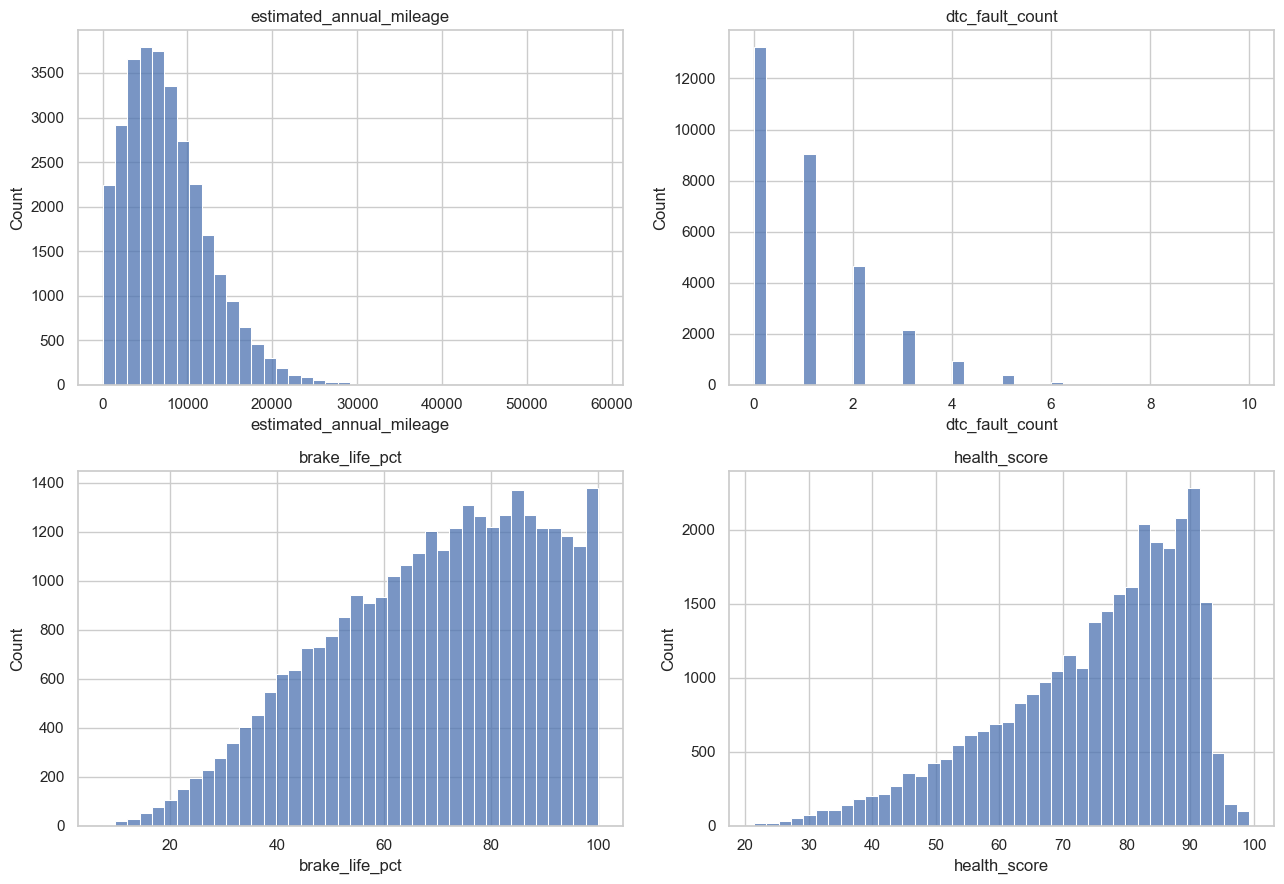

In [6]:
new_feats = ["estimated_annual_mileage", "dtc_fault_count", "brake_life_pct", "health_score"]
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
for ax, c in zip(axes.ravel(), new_feats):
    sns.histplot(df[c], bins=40, ax=ax); ax.set_title(c)
plt.tight_layout()

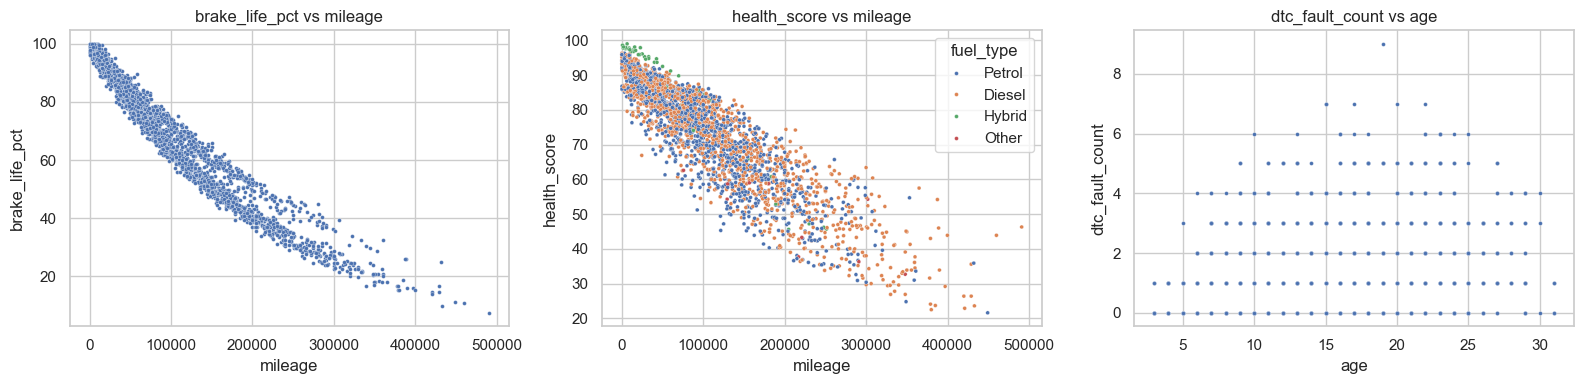

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
sample = df.sample(min(3000, len(df)), random_state=0)
sns.scatterplot(data=sample, x="mileage", y="brake_life_pct", s=8, ax=axes[0])
axes[0].set_title("brake_life_pct vs mileage")
sns.scatterplot(data=sample, x="mileage", y="health_score", hue="fuel_type", s=8, ax=axes[1])
axes[1].set_title("health_score vs mileage")
sns.scatterplot(data=sample, x="age", y="dtc_fault_count", s=8, ax=axes[2])
axes[2].set_title("dtc_fault_count vs age")
plt.tight_layout()

In [8]:
# Directional correlation with price (expect health_score +, fault/annual_mileage -).
corr = df[new_feats + ["price_rm"]].corr()["price_rm"].drop("price_rm").sort_values()
print("correlation of new features with price_rm:")
print(corr.round(3))

correlation of new features with price_rm:
dtc_fault_count            -0.256
estimated_annual_mileage   -0.242
health_score                0.419
brake_life_pct              0.464
Name: price_rm, dtype: float64


## 5 · Write model-ready dataset to `data/processed/`

In [9]:
OUT_PATH.parent.mkdir(parents=True, exist_ok=True)
df.to_csv(OUT_PATH, index=False)
print("wrote:", OUT_PATH)
print("final shape:", df.shape)
print("\ncolumns:")
print(list(df.columns))
print("\nrow-count ledger:")
print(pd.DataFrame(ledger, columns=["step", "rows"]).to_string(index=False))

wrote: C:\Users\Chan Zheng Shao\OneDrive\Desktop\Github Repo\Clorox_Mercedes_26\data\processed\merc_processed.csv
final shape: (30587, 29)

columns:
['model_class', 'year', 'mileage', 'transmission', 'fuel_type', 'engine_size', 'price_rm', 'source_market', 'age', 'variant', 'displacement_cc', 'n_cylinders', 'n_gears', 'top_speed_kmh', 'torque_nm', 'accel_0_100_s', 'boot_l', 'engine_config', 'aspiration', 'gear_type', 'front_brake', 'rear_brake', 'match_level', 'battery_soh', 'trans_adapt_offset', 'estimated_annual_mileage', 'dtc_fault_count', 'brake_life_pct', 'health_score']

row-count ledger:
                                           step  rows
                                         loaded 36819
                      drop 7 duplicate listings 36812
   backfill 10 engine_size==0 from displacement 36812
                null 5 broken torque_nm (>2000) 36812
              drop constant spec_matched column 36812
complete-case drop 6225 rows with missing specs 30587


## 6 · Summary

**Cleaning applied** (interim → processed): removed duplicate listings; backfilled
mis-coded `engine_size == 0` from `displacement_cc`; nulled broken `torque_nm`; dropped the
constant `spec_matched` column; complete-case dropped rows with any missing spec value.
`price_rm` is untouched, so its distribution is unchanged.

**New features — all grounded in existing columns:**
- `estimated_annual_mileage` = `mileage / age` — usage intensity; low km/yr signals a
  well-kept car (negatively correlated with wear).
- `dtc_fault_count` — seeded Poisson around a wear mean in `age` + `mileage`.
- `brake_life_pct` — exponential wear in `mileage`, decay rate set by the real
  `front_brake`/`rear_brake` type, worse axle wins.
- `health_score` (0–100) — penalty aggregation of the **real** `battery_soh` /
  `trans_adapt_offset` / `mileage` plus the grounded fault & brake features.

**Modeling note:** the EDA recommended predicting `log1p(price_rm)`; that transform stays a
modeling-time step and is intentionally not baked into this file.

**Other grounded avenues (not built here)** — all derivable from existing columns:
specific output `torque_nm / displacement_cc` (engine stress); a DPF-load proxy for
`fuel_type == "Diesel"` from `mileage`; a thermal-stress proxy from `aspiration` (turbo) +
`mileage`; a drivetrain-wear index from the real `trans_adapt_offset`. Service history,
coolant/battery snapshots, and real DTC readouts are **not** derivable from this dataset and
were deliberately excluded to avoid fabricating data.